<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 6px 15px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h1 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 36px; font-weight: bold; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 10px;">
    Customer Support ChatBot
  </h1>
  <p style="color: #5D6D7E; font-family: 'Arial', sans-serif; font-size: 18px; line-height: 1.6; margin-top: 0;">
    Classification for users Problem's Intent and Category 
  </p>
  <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
  <p style="color: #85929E; font-family: 'Arial', sans-serif; font-size: 14px; margin-top: 10px;">
    Powered by RoBERTa Transformer and Dual Classification 
  </p>
</div>

<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Importing Required Libraries
  </h2>
  
  <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
  

In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch import nn
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    DataCollatorWithPadding,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Read Data and Get Some Info About It
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>



The Bitext dataset ships as a single HuggingFace `train` split with 26,872 rows.  
We convert it to pandas and create our own train/val/test splits.

**Dataset columns we use:**
- `instruction` → the customer utterance (our input text)
- `category` → 11 high-level intent categories  
- `intent` → 27 fine-grained intent labels  
- `flags` → linguistic variation tags (B=basic, C=colloquial, Q=question, etc.) — kept for reference

In [ ]:
raw = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")
df = raw["train"].to_pandas()

print(f"Raw shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print()
df[["instruction", "category", "intent", "flags"]].sample(5)

README.md: 0.00B [00:00, ?B/s]

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Raw shape: (26872, 5)
Columns: ['flags', 'instruction', 'category', 'intent', 'response']



,instruction,category,intent,flags
9329,I can't talk with a human agent,CONTACT,contact_human_agent,BLZ
4160,I have got to locate hte bills from {{Person N...,INVOICE,check_invoice,BLMZ
18500,"I cannot pay, help me to inform of a problem w...",PAYMENT,payment_issue,BCELM
8840,I want help speaking to customer service,CONTACT,contact_customer_service,BL
5098,I try to see th accepted payment options,PAYMENT,check_payment_methods,BLZ




Set `LABEL_MODE` to either:
- `"category"` — 11 classes, easier task, higher expected accuracy (~93%+)
- `"intent"` — 27 classes, richer and more useful for real routing, still very learnable (~87%+)

In [ ]:
# ── CONFIGURE HERE ────────────────────────────────────────────────────────────
LABEL_MODE = "category"   # "category" (11 classes) OR "intent" (27 classes)
# ─────────────────────────────────────────────────────────────────────────────

assert LABEL_MODE in ("category", "intent"), "LABEL_MODE must be 'category' or 'intent'"

LABEL_COL = LABEL_MODE  

df = df.dropna(subset=["instruction", LABEL_COL]).copy()

CLASSES = sorted(df[LABEL_COL].unique())
NUM_LABELS = len(CLASSES)
label2id = {label: i for i, label in enumerate(CLASSES)}
id2label = {i: label for label, i in label2id.items()}

df["label"] = df[LABEL_COL].map(label2id)

print(f"Mode: {LABEL_MODE.upper()} classification")
print(f"Number of classes: {NUM_LABELS}")
print(f"\nClasses:")
for i, c in enumerate(CLASSES):
    print(f"  [{i:>2}] {c}")

Mode: CATEGORY classification
Number of classes: 11

Classes:
  [ 0] ACCOUNT
  [ 1] CANCEL
  [ 2] CONTACT
  [ 3] DELIVERY
  [ 4] FEEDBACK
  [ 5] INVOICE
  [ 6] ORDER
  [ 7] PAYMENT
  [ 8] REFUND
  [ 9] SHIPPING
  [10] SUBSCRIPTION


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Data Visualization (EDA)
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

In [4]:
# ── 4.1  Basic Dataset Statistics ────────────────────────────────────────────
print("=" * 55)
print(f" DATASET OVERVIEW  ({LABEL_MODE.upper()} mode)")
print("=" * 55)
print(f"  Total samples       : {len(df):,}")
print(f"  Unique labels       : {df[LABEL_COL].nunique()}")
print(f"  Text column         : 'instruction'")
print(f"  Missing instruction : {df['instruction'].isna().sum()}")
print(f"  Missing {LABEL_COL:<12} : {df[LABEL_COL].isna().sum()}")
print()

# Utterance length
df["text_len"] = df["instruction"].apply(lambda x: len(str(x).split()))
print("  Utterance word-count statistics:")
print(df["text_len"].describe().rename({
    "count": "  count", "mean": "  mean", "std": "  std",
    "min": "  min", "25%": "  25%", "50%": "  median",
    "75%": "  75%", "max": "  max"
}).to_string())
print()

# Samples per class
vc = df[LABEL_COL].value_counts()
print("  Samples per label:")
print(f"    min  = {vc.min():,}  ({vc.idxmin()})")
print(f"    max  = {vc.max():,}  ({vc.idxmax()})")
print(f"    mean = {vc.mean():.0f}")
print(f"    imbalance ratio (max/min) = {vc.max()/vc.min():.2f}x")


 DATASET OVERVIEW  (CATEGORY mode)
  Total samples       : 26,872
  Unique labels       : 11
  Text column         : 'instruction'
  Missing instruction : 0
  Missing category     : 0

  Utterance word-count statistics:
count     26872.000000
mean          8.690979
std           2.605004
min           1.000000
25%           7.000000
median        9.000000
75%          11.000000
max          16.000000

  Samples per label:
    min  = 950  (CANCEL)
    max  = 5,986  (ACCOUNT)
    mean = 2443
    imbalance ratio (max/min) = 6.30x


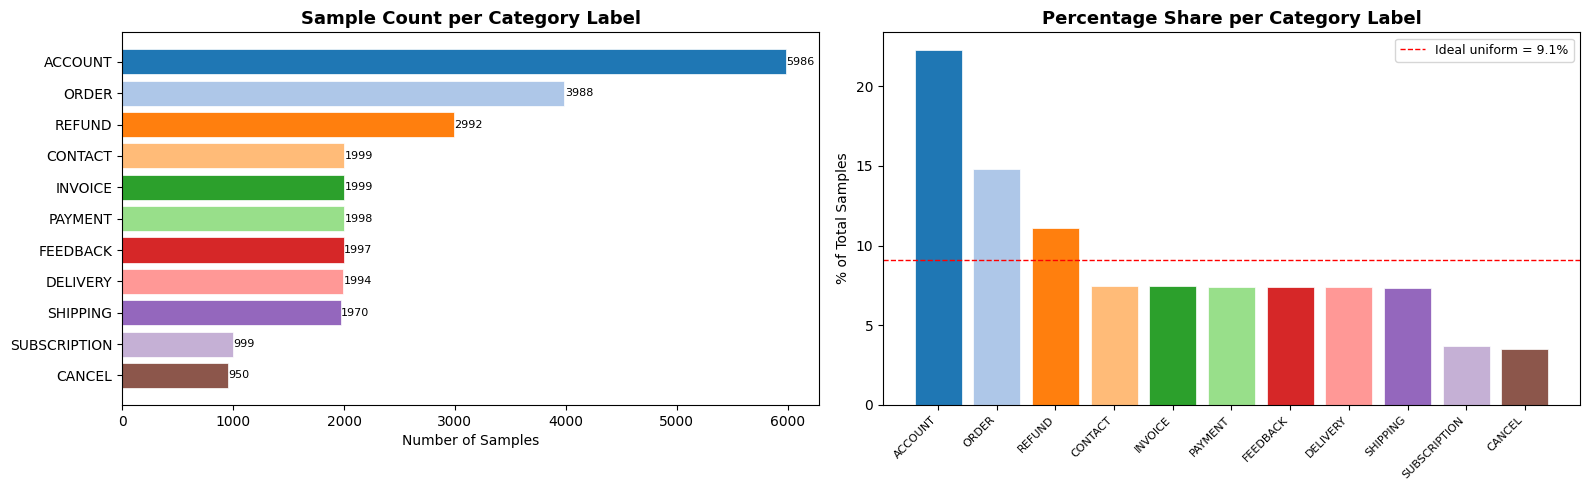

Label distribution (CATEGORY):
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
CONTACT         1999
INVOICE         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950


In [5]:
# ── 4.2  Label Distribution ───────────────────────────────────────────────────
counts = df[LABEL_COL].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, len(counts) * 0.38)))

# --- Horizontal bar chart ---
colors = plt.cm.tab20.colors if len(counts) <= 20 else plt.cm.tab20b.colors
bar_colors = [colors[i % len(colors)] for i in range(len(counts))]
axes[0].barh(counts.index, counts.values, color=bar_colors, edgecolor="white", linewidth=0.5)
axes[0].set_title(f"Sample Count per {LABEL_MODE.capitalize()} Label", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Number of Samples")
axes[0].invert_yaxis()
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(val + 5, i, str(val), va="center", fontsize=8)

# --- Percentage pie / bar ---
pct = counts / counts.sum() * 100
axes[1].bar(range(len(counts)), pct.values, color=bar_colors, edgecolor="white", linewidth=0.5)
axes[1].set_xticks(range(len(counts)))
axes[1].set_xticklabels(counts.index, rotation=45, ha="right", fontsize=8)
axes[1].set_title(f"Percentage Share per {LABEL_MODE.capitalize()} Label", fontsize=13, fontweight="bold")
axes[1].set_ylabel("% of Total Samples")
axes[1].axhline(100 / len(counts), color="red", linestyle="--", linewidth=1,
                label=f"Ideal uniform = {100/len(counts):.1f}%")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"eda_label_distribution_{LABEL_MODE}.png", dpi=150)
plt.show()

print(f"Label distribution ({LABEL_MODE.upper()}):")
print(counts.to_string())


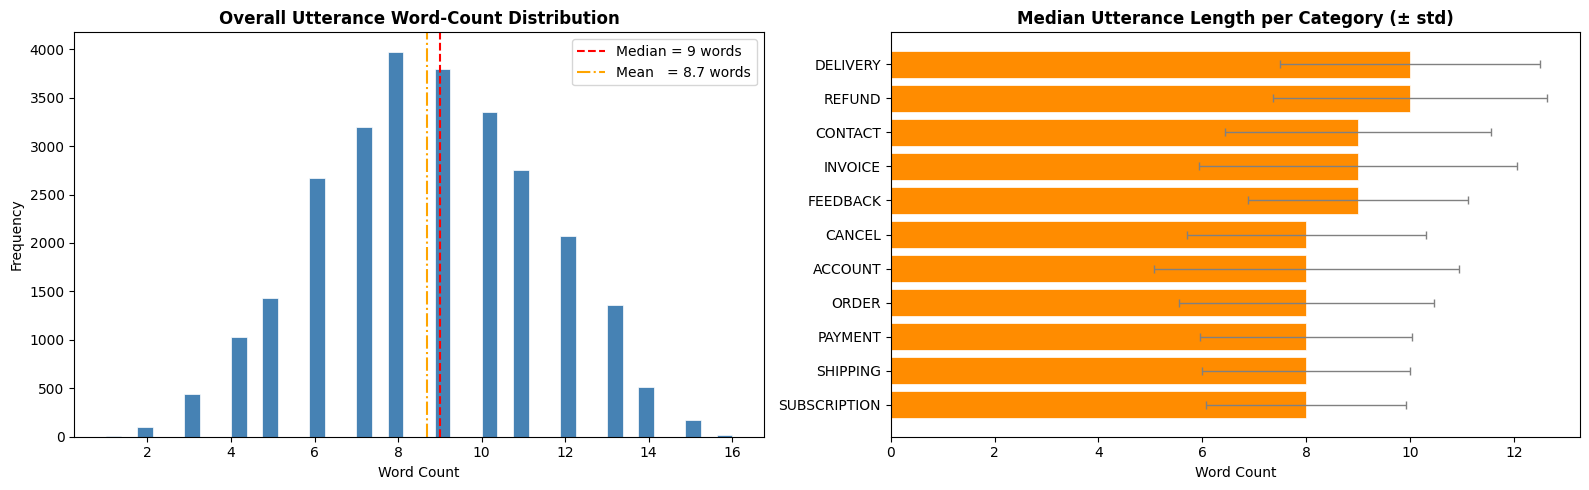

In [6]:
# ── 4.3  Utterance Length Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Overall histogram ---
axes[0].hist(df["text_len"], bins=40, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].axvline(df["text_len"].median(), color="red", linestyle="--", linewidth=1.5,
                label=f"Median = {df['text_len'].median():.0f} words")
axes[0].axvline(df["text_len"].mean(), color="orange", linestyle="-.", linewidth=1.5,
                label=f"Mean   = {df['text_len'].mean():.1f} words")
axes[0].set_title("Overall Utterance Word-Count Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# --- Median length per class (box-like bar) ---
median_len = df.groupby(LABEL_COL)["text_len"].median().sort_values(ascending=False)
std_len    = df.groupby(LABEL_COL)["text_len"].std().reindex(median_len.index)

axes[1].barh(median_len.index, median_len.values,
             xerr=std_len.values, color="darkorange",
             error_kw=dict(ecolor="gray", linewidth=1, capsize=3),
             edgecolor="white", linewidth=0.5)
axes[1].set_title(f"Median Utterance Length per {LABEL_MODE.capitalize()} (± std)",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Word Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"eda_utterance_length_{LABEL_MODE}.png", dpi=150)
plt.show()




*   **Micro-Text Corpus:** The texts are extremely short. The overall distribution is slightly right-skewed, with a median of **9 words** and a mean of **8.7 words**. Utterances rarely exceed 15 words.
*   **Length is Not a Predictive Feature:** The median length across all 11 categories is remarkably uniform (ranging tightly between 8 and 10 words). The standard deviations ($\pm$ std) show massive overlap between classes.
*   **Implications for Modeling:**
    *   **Feature Engineering:** Do not rely on text length as a feature for classification; it provides zero discriminatory power.
    *   **Algorithm Choice:** Because utterances are so short, traditional Bag-of-Words (BoW) or basic TF-IDF approaches might struggle due to a lack of deep context. **Dense embeddings** (like Word2Vec, FastText) or **Transformer-based models** (like BERT, RoBERTa, or specialized Sentence Transformers) are highly recommended, as they can extract maximum semantic meaning from a limited word count.

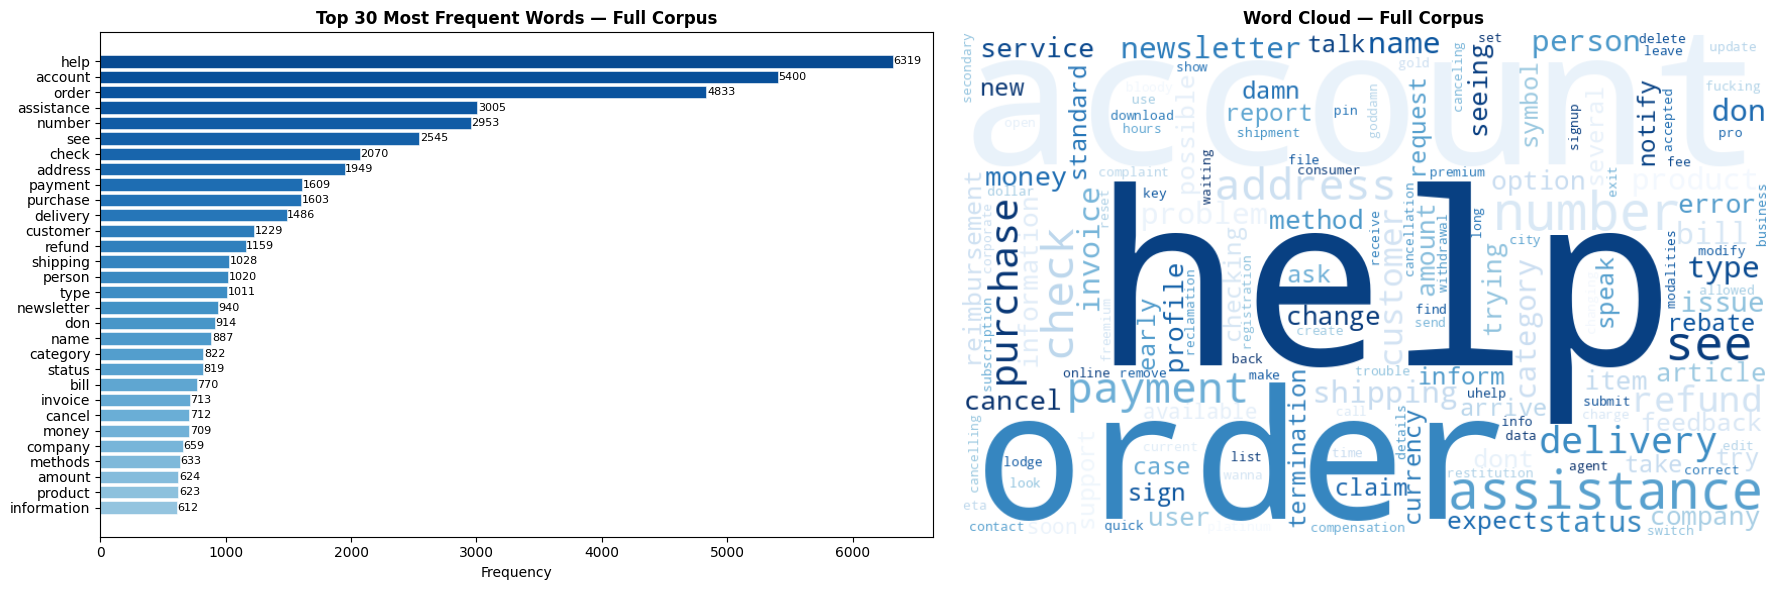

Unique words in corpus (after stopword removal): 2,720

Top 30 words:
  help                       6,319  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  account                    5,400  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  order                      4,833  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  assistance                 3,005  ████████████████████████████████████████████████████████████████████████████████████████████████████
  number                     2,953  ███████████████████████████████████████████████████████████████████████████████████████████████

In [7]:
# ── 4.4  Most Frequent Words — Corpus-wide ───────────────────────────────────
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

# Extended stopword list tailored to this domain
CUSTOM_STOPWORDS = set(STOPWORDS) | {
    "i", "my", "me", "the", "a", "an", "to", "of", "and", "is", "it",
    "in", "for", "on", "with", "that", "this", "you", "your", "we",
    "our", "be", "have", "has", "had", "do", "did", "not", "was",
    "are", "from", "at", "by", "or", "but", "if", "as", "so", "up",
    "can", "could", "would", "will", "get", "got", "just", "about",
    "how", "what", "when", "there", "been", "they", "them", "their",
    "also", "want", "need", "like", "know", "please", "hi", "hello",
}

def tokenize_text(text):
    """Lowercase, remove punctuation, split into words, drop stopwords."""
    words = re.sub(r"[^\w\s]", " ", str(text).lower()).split()
    return [w for w in words if w not in CUSTOM_STOPWORDS and len(w) > 2]

# Build corpus-wide word frequency
all_words = []
for text in df["instruction"]:
    all_words.extend(tokenize_text(text))

word_freq = Counter(all_words)
top_n = 30
top_words = word_freq.most_common(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Bar chart of top words ---
words_list, counts_list = zip(*top_words)
palette = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]
axes[0].barh(words_list, counts_list, color=palette, edgecolor="white", linewidth=0.4)
axes[0].set_title(f"Top {top_n} Most Frequent Words — Full Corpus", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Frequency")
axes[0].invert_yaxis()
for i, (w, c) in enumerate(zip(words_list, counts_list)):
    axes[0].text(c + 5, i, str(c), va="center", fontsize=8)

# --- Word cloud ---
wc_text = " ".join(all_words)
wc = WordCloud(
    width=800, height=500,
    background_color="white",
    colormap="Blues",
    max_words=150,
    collocations=False,
).generate(wc_text)

axes[1].imshow(wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud — Full Corpus", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(f"eda_top_words_corpus_{LABEL_MODE}.png", dpi=150)
plt.show()

print(f"Unique words in corpus (after stopword removal): {len(word_freq):,}")
print(f"\nTop {top_n} words:")
for w, c in top_words:
    bar = "█" * (c // max(1, counts_list[-1] // 20))
    print(f"  {w:<25} {c:>6,}  {bar}")




*   **Label-Vocabulary Alignment:** There is a direct and strong correlation between the most frequent unigrams and the class labels themselves. Words like "help", "account" (the #2 word overall), "order" (the #3 word overall), "payment", and "refund" dominate the corpus.
*   **Cleaned Text Evident:** Standard English stop-words (e.g., "the", "a", "is") are completely absent from the top 30 list, indicating that fundamental text preprocessing has already been applied.
*   **Implications for Modeling:**
    *   **Data Leakage Check:** Ensure that the system assigning labels didn't automatically do so just based on the presence of these exact keywords, otherwise the ML model will just learn a simple rule-based mapping rather than true intent.
    *   **Disambiguation Needs:** Because generic terms like "help", "assistance", "check", and "information" are so frequent, the model will need to rely heavily on bi-grams, tri-grams, or contextual embeddings to separate an `ACCOUNT` help request from a `SHIPPING` help request.


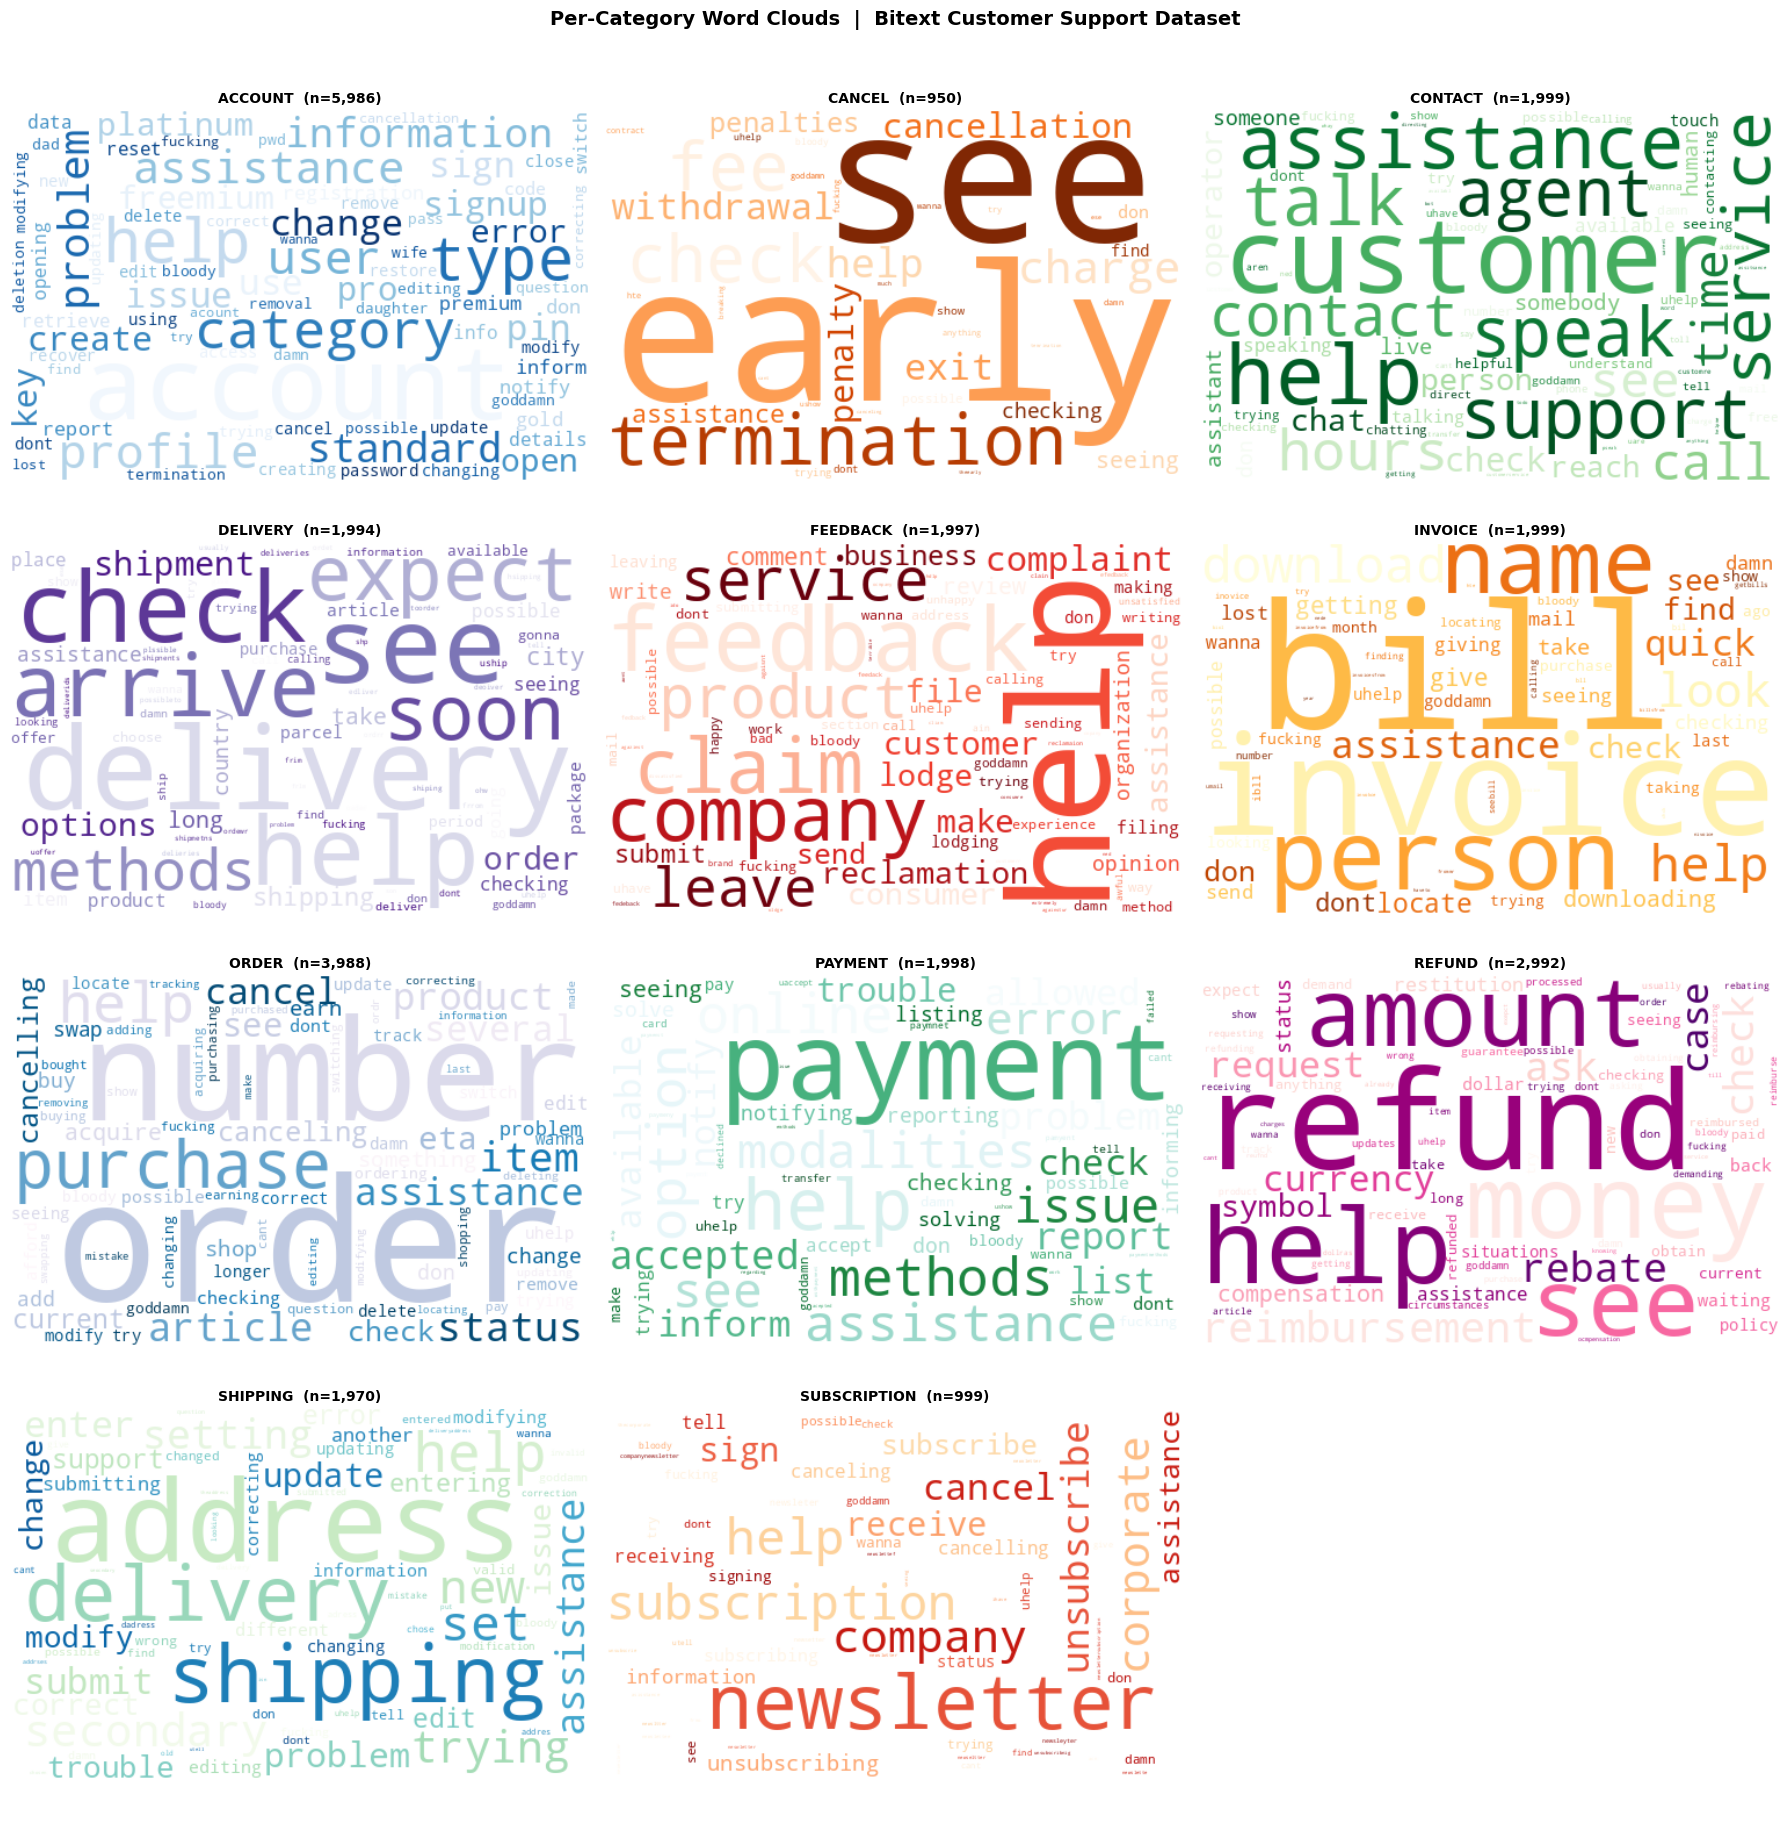

In [8]:
# ── 4.5  Per-Class Word Clouds ────────────────────────────────────────────────
# Grid layout: 3 columns, auto rows
n_classes = len(CLASSES)
n_cols = 3
n_rows = (n_classes + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4.5))
axes_flat = axes.flatten() if n_classes > 1 else [axes]

COLORMAPS = [
    "Blues", "Oranges", "Greens", "Purples", "Reds",
    "YlOrBr", "PuBu", "BuGn", "RdPu", "GnBu",
    "OrRd", "BuPu", "YlGn", "PuRd", "Greys",
    "plasma", "viridis", "magma", "cividis", "inferno",
    "cool", "hot", "copper", "spring", "summer", "autumn", "winter"
]

for idx, cls in enumerate(CLASSES):
    ax = axes_flat[idx]
    subset = df[df[LABEL_COL] == cls]["instruction"]
    class_words = []
    for text in subset:
        class_words.extend(tokenize_text(text))

    if not class_words:
        ax.axis("off")
        ax.set_title(cls, fontsize=10)
        continue

    cmap = COLORMAPS[idx % len(COLORMAPS)]
    wc = WordCloud(
        width=500, height=320,
        background_color="white",
        colormap=cmap,
        max_words=80,
        collocations=False,
    ).generate(" ".join(class_words))

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{cls}  (n={len(subset):,})", fontsize=10, fontweight="bold", pad=6)

# Hide unused subplot slots
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].axis("off")

fig.suptitle(
    f"Per-{LABEL_MODE.capitalize()} Word Clouds  |  Bitext Customer Support Dataset",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(f"eda_per_class_wordclouds_{LABEL_MODE}.png", dpi=150, bbox_inches="tight")
plt.show()


 TOP-10 WORDS PER CATEGORY CLASS

  [ACCOUNT]
    account                5,400
    help                   1,069
    type                   1,011
    category                 822
    user                     602
    profile                  591
    assistance               538
    standard                 448
    information              445
    change                   375

  [CANCEL]
    early                    363
    see                      349
    termination              340
    check                    306
    help                     242
    withdrawal               194
    exit                     194
    cancellation             175
    penalty                  167
    fees                     158

  [CONTACT]
    customer                 953
    help                     542
    assistance               438
    support                  381
    speak                    371
    talk                     370
    agent                    351
    service                  343
    c

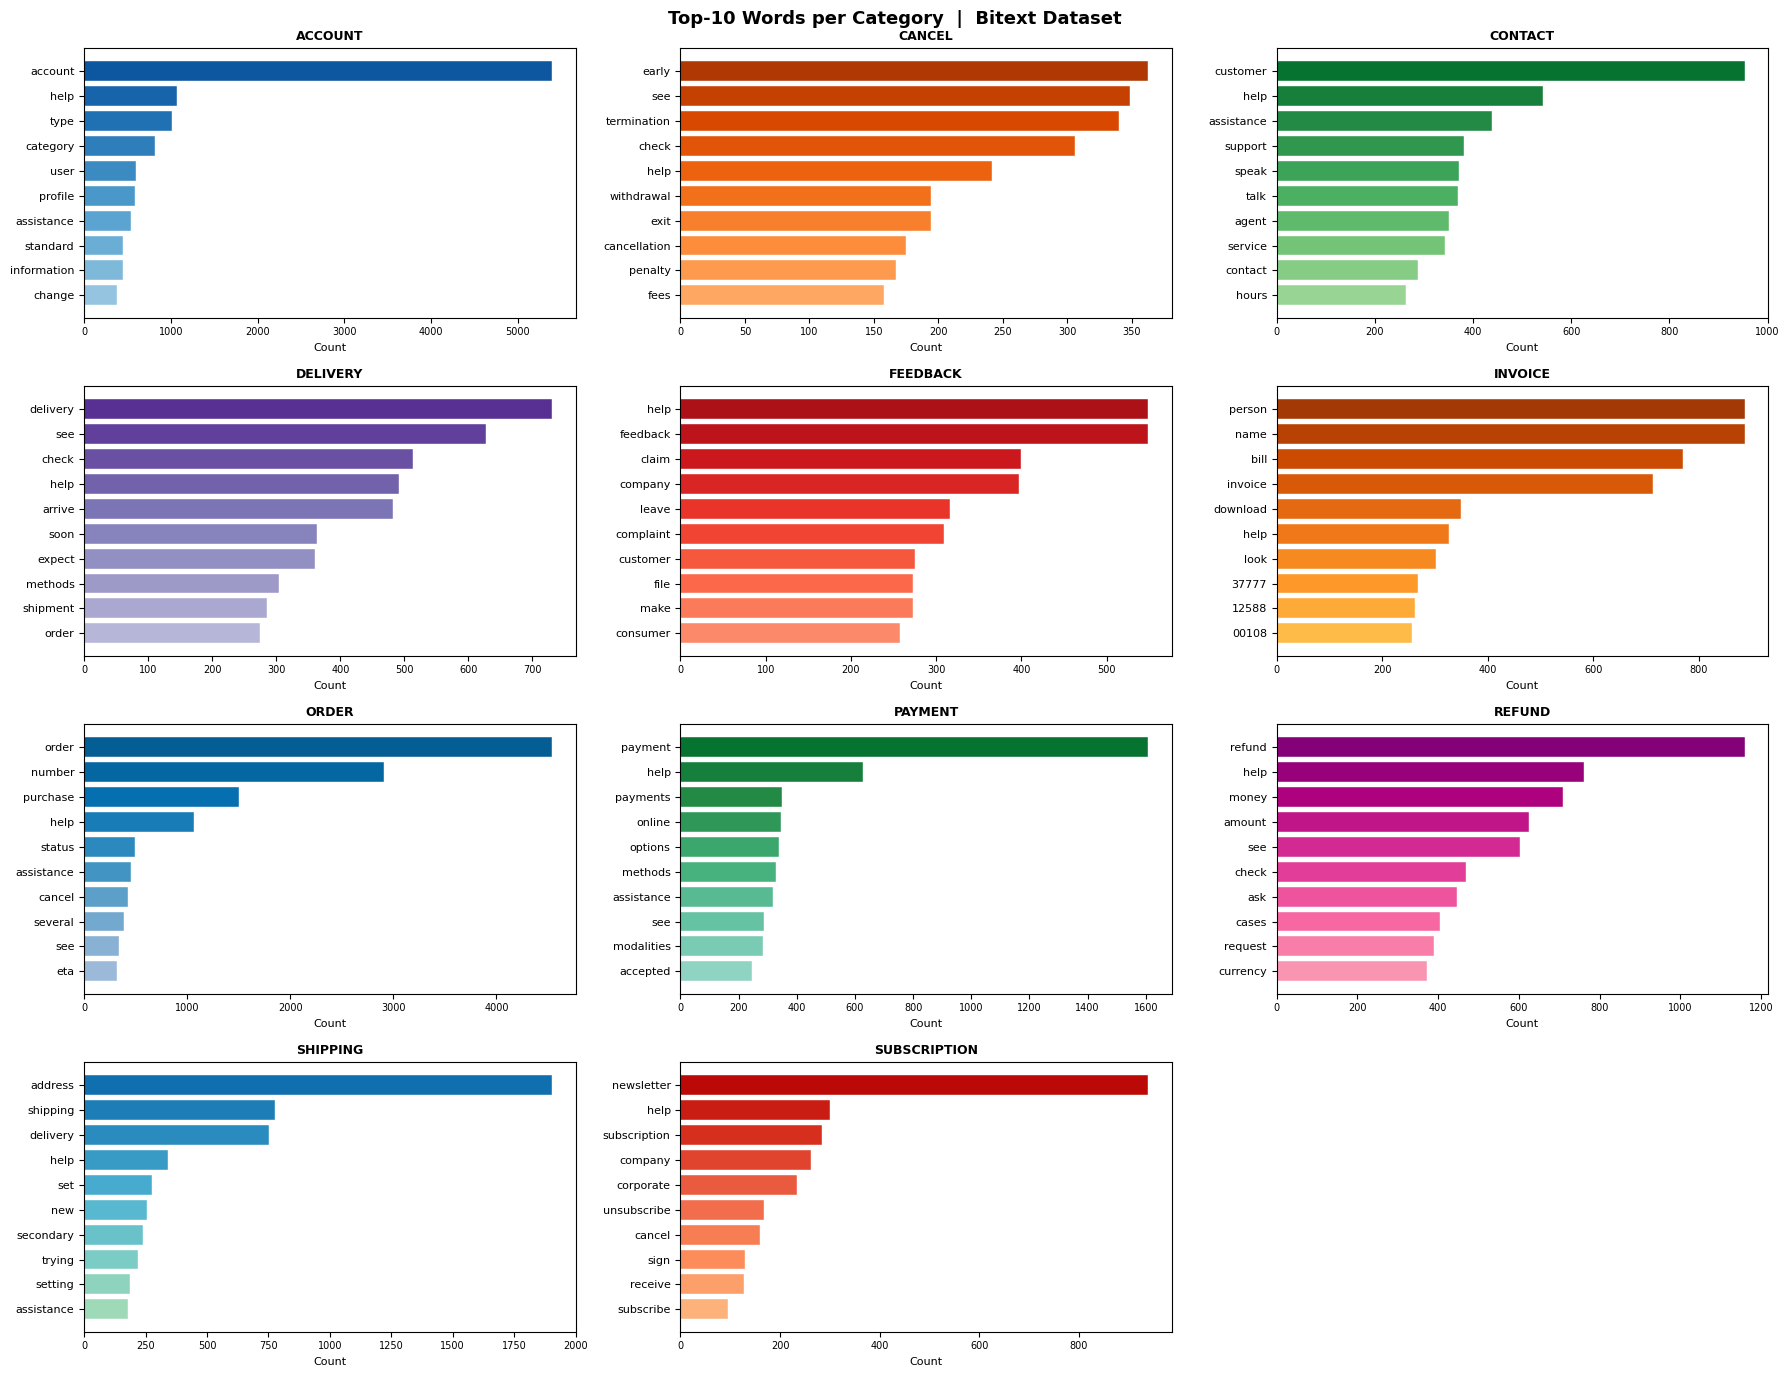

In [9]:
# ── 4.6  Top-10 Words per Class ───────────────────────────────────────────────
TOP_K = 10
n_cols_bar = min(3, n_classes)
n_rows_bar = (n_classes + n_cols_bar - 1) // n_cols_bar

fig, axes = plt.subplots(n_rows_bar, n_cols_bar,
                         figsize=(6 * n_cols_bar, 3.5 * n_rows_bar))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

print(f"{'='*60}")
print(f" TOP-{TOP_K} WORDS PER {LABEL_MODE.upper()} CLASS")
print(f"{'='*60}")

for idx, cls in enumerate(CLASSES):
    ax = axes_flat[idx]
    subset = df[df[LABEL_COL] == cls]["instruction"]
    class_words = []
    for text in subset:
        class_words.extend(tokenize_text(text))

    top_k = Counter(class_words).most_common(TOP_K)
    if not top_k:
        ax.axis("off")
        continue

    words_k, counts_k = zip(*top_k)
    cmap = COLORMAPS[idx % len(COLORMAPS)]
    colors_k = plt.get_cmap(cmap)(np.linspace(0.4, 0.85, TOP_K))[::-1]

    ax.barh(words_k, counts_k, color=colors_k, edgecolor="white", linewidth=0.3)
    ax.set_title(cls, fontsize=9, fontweight="bold")
    ax.set_xlabel("Count", fontsize=8)
    ax.invert_yaxis()
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=7)

    # Print to console
    print(f"\n  [{cls}]")
    for w, c in top_k:
        print(f"    {w:<22} {c:>5,}")

# Hide unused axes
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].axis("off")

fig.suptitle(
    f"Top-{TOP_K} Words per {LABEL_MODE.capitalize()}  |  Bitext Dataset",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(f"eda_top_words_per_class_{LABEL_MODE}.png", dpi=150, bbox_inches="tight")
plt.show()


*   **High Intra-Class Keyword Dependency:** The target labels are highly correlated with their namesake tokens. For example, the top word for `ACCOUNT` is "account," `ORDER` is "order," and `REFUND` is "refund." 
*   **The Overlap Challenge (Inter-Class Confusion):**
    *   **Generic Support Verbs:** Words like *help*, *assistance*, *see*, and *check* appear in the top 10 for almost every single category. This confirms that basic Bag-of-Words (BoW) models will struggle heavily with false positives.
    *   **Semantic Proximity:** There is dangerous semantic overlap between specific classes. Notably, `SHIPPING` and `DELIVERY` share extensive vocabulary (e.g., "delivery" is the #3 word in the `SHIPPING` class). Distinguishing between a user asking about a shipping address versus a delivery ETA will require models capable of deep contextual understanding.
*   **Data Artifacts Detected (`INVOICE` class):** The `INVOICE` category's top-10 list contains specific numeric strings (e.g., *37777*, *12588*, *00108*). This is a strong signal of **unmasked Personally Identifiable Information (PII) or repetitive synthetic templates**. If not addressed, the model might overfit to these specific strings rather than learning the general concept of an invoice request.
*   **Profanity & Emotion:** The word clouds reveal a subtle undercurrent of profanity (*"fucking"*, *"goddamn"*, *"damn"*, *"bloody"*) scattered across multiple categories, indicating frustrated customer intents.

## Text Cleaning 

In [10]:
def clean_text(text: str) -> str:
    """Light cleaning for Bitext utterances — preserve linguistic diversity."""
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", "", text)   # remove URLs (rare in this dataset)
    text = re.sub(r"<.*?>", "", text)               # remove any HTML tags
    text = re.sub(r"\s+", " ", text).strip()        # normalize whitespace
    return text

df["text"] = df["instruction"].apply(clean_text)

# Verify — show samples per class
print("Sample utterances per class:")
for cls in CLASSES[:5]:  # show first 5 classes
    sample = df[df[LABEL_COL] == cls]["text"].iloc[0]
    print(f"  [{cls}] {sample[:100]}")

Sample utterances per class:
  [ACCOUNT] new {{Account Type}} acount for wife
  [CANCEL] I can't ifnd the bloody termination charge, I need help
  [CONTACT] I want help to speak to customer support
  [DELIVERY] could you help me check what delivery methods you offer?
  [FEEDBACK] help me to file a claim


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Spliting Data   
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

 
- **70%** training  
- **15%** validation (model selection / early stopping)  
- **15%** test (final evaluation untouched until the end)

In [ ]:
X = df["text"].values
y = df["label"].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)

# Step 2: split remaining into 70% train / 15% val (≈ 82.4% / 17.6% of trainval)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15 / 0.85,   # ensures final ratio is 70/15/15
    random_state=SEED,
    stratify=y_trainval
)

total = len(X)
print(f"Total samples:  {total:>6,}")
print(f"Train:          {len(X_train):>6,} ({len(X_train)/total*100:.1f}%)")
print(f"Validation:     {len(X_val):>6,} ({len(X_val)/total*100:.1f}%)")
print(f"Test:           {len(X_test):>6,} ({len(X_test)/total*100:.1f}%)")

# Verify stratification
print(f"\nClass balance check (train label std): {np.std(np.bincount(y_train)):.1f} (lower = more balanced)")

Total samples:  26,872
Train:          18,810 (70.0%)
Validation:      4,031 (15.0%)
Test:            4,031 (15.0%)

Class balance check (train label std): 961.9 (lower = more balanced)


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Class Weights To Handel The Imbalancing  
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

In [13]:
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=y_train
)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float).to(DEVICE)

print(f"Class weight range: [{class_weights_np.min():.4f}, {class_weights_np.max():.4f}]")
print(f"Mean weight: {class_weights_np.mean():.4f}")
print()
print("Weights per class:")
for i, (cls, w) in enumerate(zip(CLASSES, class_weights_np)):
    print(f"  [{i:>2}] {cls:<35} → {w:.4f}")

Class weight range: [0.4081, 2.5676]
Mean weight: 1.2915

Weights per class:
  [ 0] ACCOUNT                             → 0.4081
  [ 1] CANCEL                              → 2.5676
  [ 2] CONTACT                             → 1.2223
  [ 3] DELIVERY                            → 1.2249
  [ 4] FEEDBACK                            → 1.2232
  [ 5] INVOICE                             → 1.2223
  [ 6] ORDER                               → 0.6125
  [ 7] PAYMENT                             → 1.2232
  [ 8] REFUND                              → 0.8166
  [ 9] SHIPPING                            → 1.2400
  [10] SUBSCRIPTION                        → 2.4464


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Tokenization  
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>



**Model:** `roberta-base` strong general-purpose encoder, excellent on short-to-medium utterances.

**Max length:** 64 tokens. Bitext utterances are short (avg ~10 words, max ~25).  
Using 64 instead of 256 reduces memory usage by 4× and speeds up training significantly with no accuracy loss.

**Dynamic padding** via `DataCollatorWithPadding` pads per batch to the longest sequence in that batch.

In [ ]:
MODEL_NAME = "roberta-base"
MAX_LENGTH = 64   # Bitext utterances are short — 64 tokens is more than enough

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        
    )

def make_hf_dataset(texts, labels):
    ds = Dataset.from_dict({"text": list(texts), "label": list(labels)})
    ds = ds.map(tokenize, batched=True, remove_columns=["text"])
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    return ds

train_dataset = make_hf_dataset(X_train, y_train)
val_dataset   = make_hf_dataset(X_val,   y_val)
test_dataset  = make_hf_dataset(X_test,  y_test)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"Train: {train_dataset}")
print(f"Val:   {val_dataset}")
print(f"Test:  {test_dataset}")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/18810 [00:00<?, ? examples/s]

Map:   0%|          | 0/4031 [00:00<?, ? examples/s]

Map:   0%|          | 0/4031 [00:00<?, ? examples/s]

Train: Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 18810
})
Val:   Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 4031
})
Test:  Dataset({
    features: ['label', 'input_ids', 'attention_mask'],
    num_rows: 4031
})


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Model Setup   
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

We subclass `Trainer` to inject class-weighted `CrossEntropyLoss`.  


In [15]:
class WeightedTrainer(Trainer):
    """Trainer that uses class-weighted cross-entropy loss."""

    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [16]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Classification head:  {NUM_LABELS} output classes")

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: roberta-base
Total parameters:     124,654,091
Trainable parameters: 124,654,091
Classification head:  11 output classes


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Evaluation Metrics  
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

**Primary metric: macro-F1** 


In [17]:
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    wp, wr, wf1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy":         acc,
        "macro_f1":         f1,       # PRIMARY metric for model selection
        "macro_precision":  precision,
        "macro_recall":     recall,
        "weighted_f1":      wf1,
    }

<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    training Configrations   
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>



| Setting | Value | Reason |
|---|---|---|
| `learning_rate` | 2e-5 | Standard for RoBERTa fine-tuning |
| `num_epochs` | 10 (+ early stop) | Bitext is easy will converge fast, likely ~3-5 epochs |
| `batch_size` | 32 | Utterances are short, so fits comfortably |
| `warmup_steps` | 200 | Shorter warmup dataset is clean and loss drops quickly |
| `lr_scheduler` | cosine | Smooth decay, better generalization than linear |
| `max_length` | 64 | Utterances avg ~10 words 64 is generous without waste |

In [18]:
BATCH_SIZE = 32

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE * 2,
    num_train_epochs=10,
    weight_decay=0.01,
    warmup_steps=200,
    lr_scheduler_type="cosine",
    logging_dir="./logs",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    dataloader_num_workers=2,
    report_to="none",
    seed=SEED,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [19]:
trainer = WeightedTrainer(
    class_weights=class_weights_tensor,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=3,
            early_stopping_threshold=0.001
        )
    ],
)

<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Training   
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

In [20]:
print(f"Starting training — {LABEL_MODE.upper()} classification ({NUM_LABELS} classes)")
print(f"Train samples: {len(X_train):,} | Val samples: {len(X_val):,}")
print()

train_result = trainer.train()

print("\n=== Training Summary ===")
print(f"  Runtime:        {train_result.metrics['train_runtime']:.1f}s")
print(f"  Samples/sec:    {train_result.metrics['train_samples_per_second']:.1f}")
print(f"  Final loss:     {train_result.metrics['train_loss']:.4f}")

Starting training — CATEGORY classification (11 classes)
Train samples: 18,810 | Val samples: 4,031



Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Macro Precision,Macro Recall,Weighted F1
1,0.023551,0.012294,0.998512,0.998532,0.998335,0.998735,0.998512
2,0.009944,0.009973,0.998512,0.998657,0.998686,0.998635,0.998511
3,0.003693,0.009127,0.998512,0.998508,0.998184,0.998837,0.998512
4,0.001086,0.009003,0.998760,0.998808,0.998685,0.998938,0.998760


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


=== Training Summary ===
  Runtime:        296.1s
  Samples/sec:    635.3
  Final loss:     0.2109


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Evaluation on Testset   
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

In [21]:
print("=== Validation Set Results ===")
val_results = trainer.evaluate(val_dataset)
for k, v in val_results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

print("\n=== Test Set Results (Final) ===")
test_results = trainer.evaluate(test_dataset)
for k, v in test_results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

=== Validation Set Results ===


  eval_loss: 0.0090
  eval_accuracy: 0.9988
  eval_macro_f1: 0.9988
  eval_macro_precision: 0.9987
  eval_macro_recall: 0.9989
  eval_weighted_f1: 0.9988
  eval_runtime: 3.7304
  eval_samples_per_second: 1080.5820
  eval_steps_per_second: 8.5780
  epoch: 4.0000

=== Test Set Results (Final) ===
  eval_loss: 0.0017
  eval_accuracy: 0.9998
  eval_macro_f1: 0.9996
  eval_macro_precision: 0.9998
  eval_macro_recall: 0.9994
  eval_weighted_f1: 0.9998
  eval_runtime: 3.6849
  eval_samples_per_second: 1093.9330
  eval_steps_per_second: 8.6840
  epoch: 4.0000


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Evaluation Results    
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

In [22]:
predictions_output = trainer.predict(test_dataset)
logits = predictions_output.predictions
y_pred = np.argmax(logits, axis=1)
y_true = predictions_output.label_ids

print(f"=== Per-Class Classification Report ({LABEL_MODE.upper()}) ===")
print(classification_report(y_true, y_pred, target_names=CLASSES, zero_division=0))

=== Per-Class Classification Report (CATEGORY) ===
              precision    recall  f1-score   support

     ACCOUNT       1.00      1.00      1.00       898
      CANCEL       1.00      1.00      1.00       142
     CONTACT       1.00      1.00      1.00       300
    DELIVERY       1.00      1.00      1.00       299
    FEEDBACK       1.00      1.00      1.00       300
     INVOICE       1.00      1.00      1.00       300
       ORDER       1.00      1.00      1.00       598
     PAYMENT       1.00      1.00      1.00       300
      REFUND       1.00      1.00      1.00       449
    SHIPPING       1.00      1.00      1.00       295
SUBSCRIPTION       1.00      0.99      1.00       150

    accuracy                           1.00      4031
   macro avg       1.00      1.00      1.00      4031
weighted avg       1.00      1.00      1.00      4031



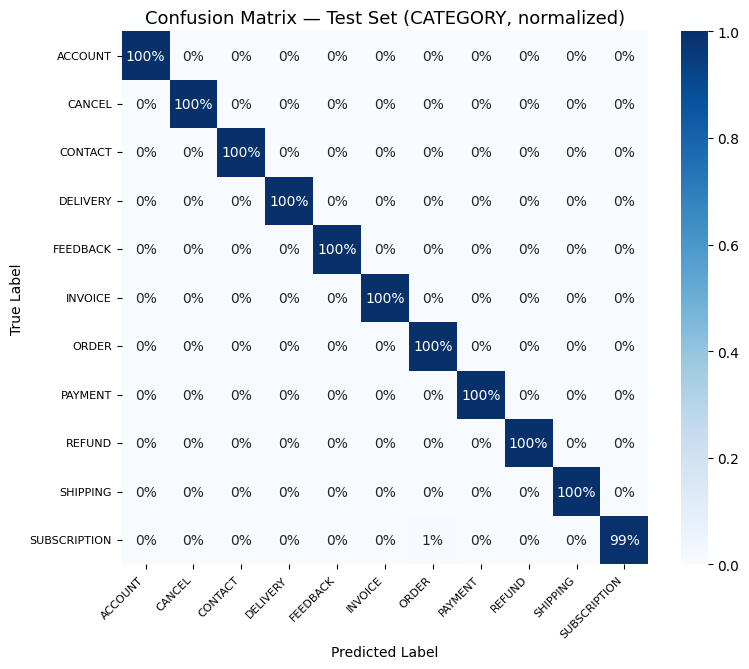

In [23]:
cm = confusion_matrix(y_true, y_pred)

# Scale figure size by number of classes
fig_size = max(8, NUM_LABELS * 0.55)
fig, ax = plt.subplots(figsize=(fig_size, fig_size * 0.85))

# Normalize to percentages for readability with many classes
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".0%",
    cmap="Blues",
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    ax=ax,
    vmin=0, vmax=1,
)
ax.set_title(f"Confusion Matrix — Test Set ({LABEL_MODE.upper()}, normalized)", fontsize=13)
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f"confusion_matrix_{LABEL_MODE}.png", dpi=150)
plt.show()

<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Training Curve Visualization   
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

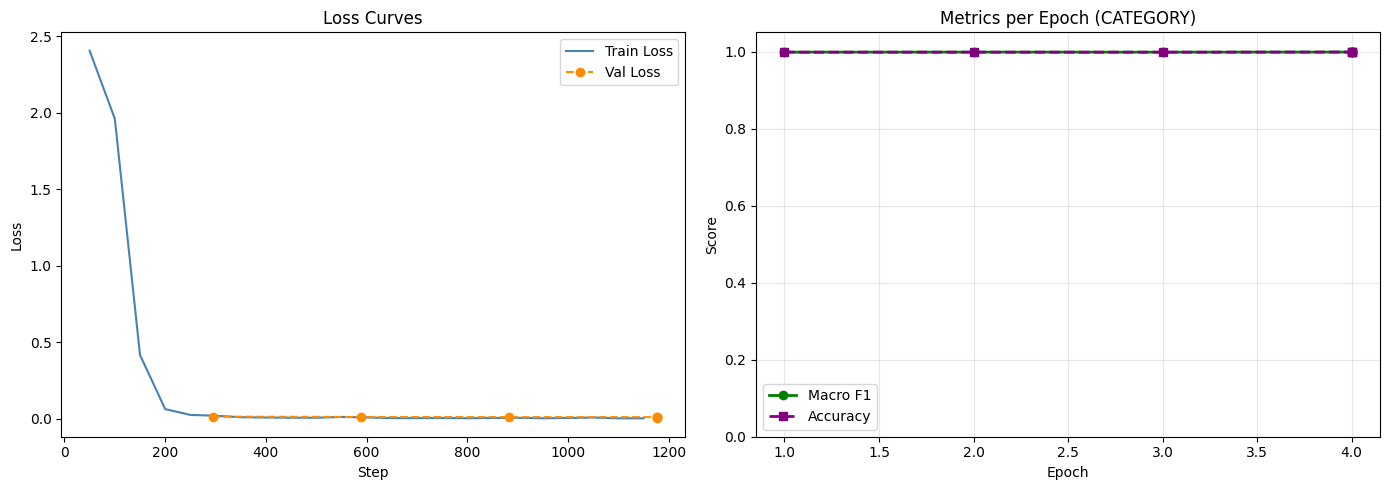

In [24]:
log_history = trainer.state.log_history

train_logs = [l for l in log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in log_history if "eval_loss" in l]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
if train_logs:
    axes[0].plot(
        [l["step"] for l in train_logs],
        [l["loss"] for l in train_logs],
        label="Train Loss", color="steelblue"
    )
if eval_logs:
    axes[0].plot(
        [l["step"] for l in eval_logs],
        [l["eval_loss"] for l in eval_logs],
        label="Val Loss", color="darkorange", linestyle="--", marker="o"
    )
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Macro F1 curve
if eval_logs and "eval_macro_f1" in eval_logs[0]:
    axes[1].plot(
        [l["epoch"] for l in eval_logs],
        [l["eval_macro_f1"] for l in eval_logs],
        marker="o", color="green", linewidth=2, label="Macro F1"
    )
    axes[1].plot(
        [l["epoch"] for l in eval_logs],
        [l["eval_accuracy"] for l in eval_logs],
        marker="s", color="purple", linewidth=2, linestyle="--", label="Accuracy"
    )
    axes[1].set_title(f"Metrics per Epoch ({LABEL_MODE.upper()})")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"training_curves_{LABEL_MODE}.png", dpi=150)
plt.show()

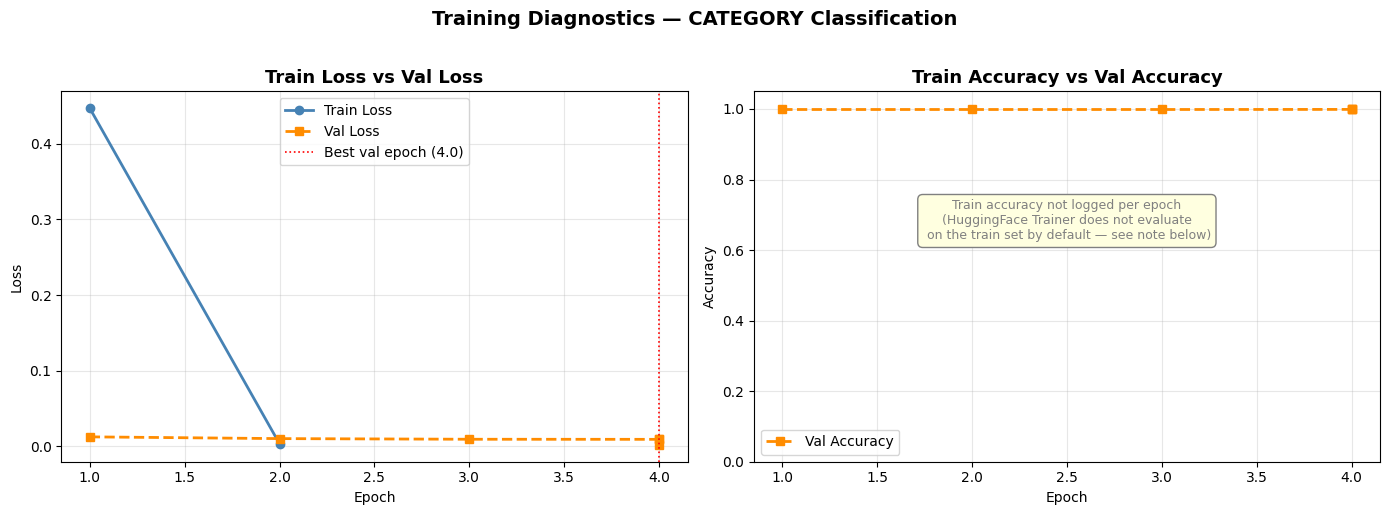

NOTE: HuggingFace Trainer does not run compute_metrics on the training set
by default (it would double training time). To log train accuracy, add:

  training_args = TrainingArguments(
      ...,
      eval_strategy='epoch',
      # add eval_on_train_epoch_end=True  ← forces eval on train set each epoch
  )

Val accuracy per epoch:
  Epoch  1.0  →  Val Acc = 0.9985
  Epoch  2.0  →  Val Acc = 0.9985
  Epoch  3.0  →  Val Acc = 0.9985
  Epoch  4.0  →  Val Acc = 0.9988
  Epoch  4.0  →  Val Acc = 0.9988
  Epoch  4.0  →  Val Acc = 0.9998


In [ ]:
log_history = trainer.state.log_history

train_logs = [l for l in log_history if "loss" in l and "eval_loss" not in l]
eval_logs  = [l for l in log_history if "eval_loss" in l]

import math
steps_per_epoch = math.ceil(len(X_train) / BATCH_SIZE)

def avg_train_metric_by_epoch(logs, key, steps_per_epoch):
    """Group train-step logs into epochs and return (epoch, avg_value) pairs."""
    epochs, values = [], []
    n_epochs = max(math.ceil(l["step"] / steps_per_epoch) for l in logs if key in l)
    for ep in range(1, n_epochs + 1):
        bucket = [l[key] for l in logs
                if key in l
                  and (ep - 1) * steps_per_epoch < l["step"] <= ep * steps_per_epoch]
        if bucket:
            epochs.append(ep)
            values.append(sum(bucket) / len(bucket))
    return epochs, values

train_loss_epochs, train_loss_vals = avg_train_metric_by_epoch(train_logs, "loss", steps_per_epoch)

eval_epochs     = [l["epoch"] for l in eval_logs]
eval_loss_vals  = [l["eval_loss"] for l in eval_logs]
eval_acc_vals   = [l.get("eval_accuracy", float("nan")) for l in eval_logs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_loss_epochs, train_loss_vals,
            color="steelblue", linewidth=2, marker="o", label="Train Loss")
axes[0].plot(eval_epochs, eval_loss_vals,
            color="darkorange", linewidth=2, linestyle="--", marker="s", label="Val Loss")
axes[0].set_title("Train Loss vs Val Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

if eval_loss_vals:
    best_ep = eval_epochs[eval_loss_vals.index(min(eval_loss_vals))]
    axes[0].axvline(best_ep, color="red", linestyle=":", linewidth=1.2,
                    label=f"Best val epoch ({best_ep})")
    axes[0].legend()


train_acc_logs = [l for l in log_history if "train_accuracy" in l]

if train_acc_logs:
    train_acc_epochs = [l["epoch"] for l in train_acc_logs]
    train_acc_vals   = [l["train_accuracy"] for l in train_acc_logs]
    axes[1].plot(train_acc_epochs, train_acc_vals,
                color="steelblue", linewidth=2, marker="o", label="Train Accuracy")
else:
    axes[1].annotate(
        "Train accuracy not logged per epoch\n"
        "(HuggingFace Trainer does not evaluate\n"
        " on the train set by default — see note below)",
        xy=(0.5, 0.6), xycoords="axes fraction",
        ha="center", fontsize=9, color="gray",
        bbox=dict(boxstyle="round,pad=0.4", fc="lightyellow", ec="gray"),
    )

axes[1].plot(eval_epochs, eval_acc_vals,
            color="darkorange", linewidth=2, linestyle="--", marker="s", label="Val Accuracy")
axes[1].set_title("Train Accuracy vs Val Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Training Diagnostics — {LABEL_MODE.upper()} Classification",
            fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"train_val_curves_{LABEL_MODE}.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Note on Train Accuracy ────────────────────────────────────────────────────
print("NOTE: HuggingFace Trainer does not run compute_metrics on the training set")
print("by default (it would double training time). To log train accuracy, add:")
print()
print("  training_args = TrainingArguments(")
print("      ...,")
print("      eval_strategy='epoch',")
print("      # add eval_on_train_epoch_end=True  ← forces eval on train set each epoch")
print("  )")
print()
print("Val accuracy per epoch:")
for ep, acc in zip(eval_epochs, eval_acc_vals):
    print(f"  Epoch {ep:>4.1f}  →  Val Acc = {acc:.4f}")


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Error Analysis   
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

In [ ]:
errors = []
for true_idx, pred_idx in zip(y_true, y_pred):
    if true_idx != pred_idx:
        errors.append((CLASSES[true_idx], CLASSES[pred_idx]))

error_counts = Counter(errors).most_common(10)

print(f"Total misclassifications: {len(errors)} / {len(y_true)} ({len(errors)/len(y_true)*100:.1f}%)")
print()
print("Top-10 most confused pairs (True → Predicted):")
print(f"{'True Label':<35} {'Predicted Label':<35} Count")
print("-" * 80)
for (true_cls, pred_cls), count in error_counts:
    print(f"{true_cls:<35} {pred_cls:<35} {count}")

Total misclassifications: 1 / 4031 (0.0%)

Top-10 most confused pairs (True → Predicted):
True Label                          Predicted Label                     Count
--------------------------------------------------------------------------------
SUBSCRIPTION                        ORDER                               1


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Save Model & Tokenizer 
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

In [27]:
SAVE_DIR = f"./best_model_{LABEL_MODE}"
trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
print(f"Model saved to: {SAVE_DIR}")
print(f"  Mode: {LABEL_MODE} | Classes: {NUM_LABELS}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./best_model_category
  Mode: category | Classes: 11


<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Live Predictions  
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=SAVE_DIR,
    tokenizer=SAVE_DIR,
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=MAX_LENGTH,
)

examples = [
    "I need to cancel my order, I ordered the wrong item",
    "where is my package? it was supposed to arrive yesterday",
    "I was charged twice on my credit card this month",
    "how do i return this and get a refund?",
    "I forgot my password and can't log into my account",
    "can u change the shipping address for order 12345",          # colloquial spelling
    "my account got hacked i think someone else is using it",
    "what payment methods do you accept?",
]

print(f"=== Live Predictions ({LABEL_MODE.upper()}) ===\n")
for text in examples:
    result = classifier(text)[0]
    label = result["label"]
    score = result["score"]
    bar = "█" * int(score * 20)
    print(f"  Input:  {text}")
    print(f"  Pred:   {label:<35} confidence: {score:.3f} {bar}")
    print()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

=== Live Predictions (CATEGORY) ===

  Input:  I need to cancel my order, I ordered the wrong item
  Pred:   ORDER                               confidence: 0.999 ███████████████████

  Input:  where is my package? it was supposed to arrive yesterday
  Pred:   DELIVERY                            confidence: 0.999 ███████████████████

  Input:  I was charged twice on my credit card this month
  Pred:   PAYMENT                             confidence: 0.997 ███████████████████

  Input:  how do i return this and get a refund?
  Pred:   REFUND                              confidence: 0.999 ███████████████████

  Input:  I forgot my password and can't log into my account
  Pred:   ACCOUNT                             confidence: 0.999 ███████████████████

  Input:  can u change the shipping address for order 12345
  Pred:   SHIPPING                            confidence: 0.977 ███████████████████

  Input:  my account got hacked i think someone else is using it
  Pred:   ACCOUNT             

<div style="background-color: #F9F9F9; padding: 40px; border-radius: 20px; box-shadow: 0px 8px 20px rgba(0, 0, 0, 0.1); margin: 20px auto; max-width: 800px; text-align: center;">
  <h2 style="color: #2C3E50; font-family: 'Georgia', serif; font-size: 26px; font-weight: bold; letter-spacing: 1.2px; text-transform: uppercase; margin-bottom: 25px;">
    Thank You   
  </h2>
    <hr style="border: none; border-top: 2px solid #AED6F1; width: 80%; margin: 20px auto;">
</div>